In [1]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using Interpolations

In [2]:
pathdir_stripe_90 = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

N = 30
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz

ω0 = 2π*ustrip(c_0)/λ

x_crop = [1100:1700;]
y_crop = [1750:2450;]

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2); # In photon/m^2/atom

### Load experimental data

In [3]:
# Stripe 90
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe
@load "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Iatoms_stripe_90, Ibkg_stripe_90, Idark_stripe_90, Mean_atoms_stripe_90, Mean_bkg_stripe_90, Mean_dark_stripe_90, Mean_bkg_atoms_stripe_90, Std_atoms_stripe_90, Std_bkg_stripe_90, Std_dark_stripe_90, Std_bkg_atoms_stripe_90 = Iatoms_stripes, Ibkg_stripes, Idark_stripes, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

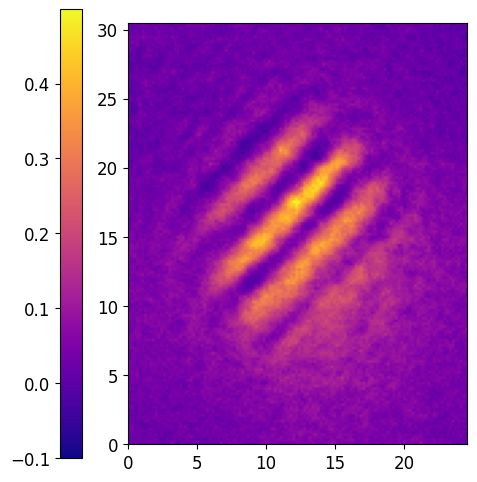

In [46]:
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" ODs_dataset

size_pxl = 0.1966; # New pxl size since 2025/12/31

rc("font", size=12)

fig, ax = subplots(figsize=(5, 5))

img = imshow(ODs_dataset[end, 4, 150:305, 125:250], cmap="plasma", extent=[0, (250-125)*size_pxl, 0, (305-150)*size_pxl], vmin=-0.1, vmax=maximum(ODs_dataset[end, 4, 150:305, 125:250]))
# xlabel(L"x (in $\mu m$)")
# ylabel(L"y (in $\mu m$)")
colorbar(img, location="left")
# axis("off")
tight_layout()
savefig("Poster_stripe_V2.png")

### Fit the saturation parameter

In [4]:
I_elec_measured = [0.1:0.1:1;]
P_measured = [0.004, 0.035, 0.15, 0.43, 0.9, 1.5, 2.1, 2.6, 3, 3.4] * 1e-3
w0 = 300.0750022524122e-6 # Fitted waist
sat_measured = 2 .* P_measured ./ (π*w0^2 * Isat * ustrip(ħ * ω0))
interp_linear = linear_interpolation(I_elec_measured, sat_measured);

In [5]:
list_factor = []
for i = 1:size(Ibkg_stripe_90)[1]
    for j = 1:size(Ibkg_stripe_90)[2]
        if Ibkg_stripe_90[i, j] > 0
            push!(list_factor, interp_linear(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j]) / (Ibkg_stripe_90[i, j]/Isat))
        end
    end
end
factor_sat = mean(list_factor);

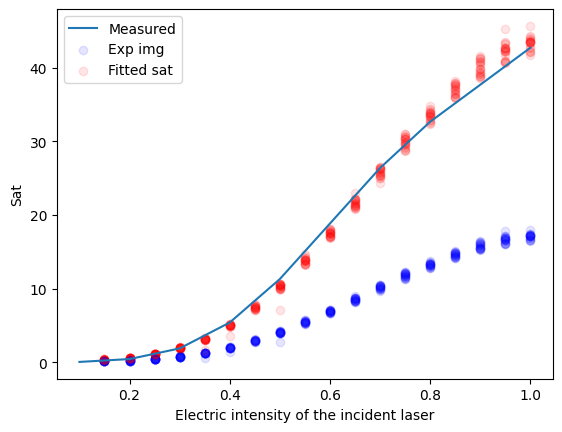

In [6]:
plot(I_elec_measured, sat_measured, label="Measured")

for i = 1:size(Ibkg_stripe_90)[1]
    for j = 1:size(Ibkg_stripe_90)[2]
        if Ibkg_stripe_90[i, j] > 0
            scatter(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j], Ibkg_stripe_90[i, j]/Isat, color="b", alpha=0.1)
            scatter(Amplitude_laser[(i-1)*size(Ibkg_stripe_90)[2]+j], (Ibkg_stripe_90[i, j]/Isat) * factor_sat, color="r", alpha=0.1)
        end
    end
end
legend(["Measured", "Exp img", "Fitted sat"])
xlabel("Electric intensity of the incident laser")
ylabel("Sat");

### Plot as a function of Sat measured from the images bkg

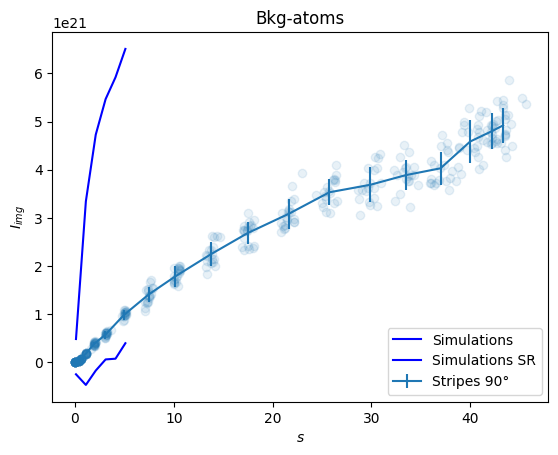

In [8]:
close("all")
fig = subplots() # figsize=(20, 10)
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Stripes 90°")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end

# Simulations
@load "Solutions_sim/Itot_N_30_Sat_0.1_to_5.1_decay_rate_up_down.jdl2" sat n_list Itot_per_stripe I_SE_SR_SS_per_stripe I_SR_SR_SS_per_stripe nbr_error_N
factor_sim_data = 0.16*mean(Nbr_atoms_per_stripe)/ (N*length(n_list)) # Collection rate * qutoient of atom nbr

plot(sat, Itot_per_stripe * factor_sim_data, label="Simulations", color="b")
plot(sat, I_SR_SR_SS_per_stripe * factor_sim_data, label="Simulations SR", color="b")

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

In [9]:
N*length(n_list)

780